# Spending Propensity Prediction

**Author:** Joe Kempson  
**Dataset:** Online Gaming Behavior Dataset  
**Target Feature:** SpendingPropensity

---

## Overview

This notebook implements the ML workflow I designed in Task 2.1, focusing primarily on predicting player spending propensity (NonSpender, Occasional, Whale) in online gaming.

### Task 2.1 Workflow Design Summary:
- **Data Quality Strategy:** Option C - Advanced Preprocessing
- **Additional Preprocessing:** StandardScaler + SMOTE for class imbalance
- **Models:** Logistic Regression, SVM (RBF), Random Forest
- **Hyperparameter Tuning**: GridSearchCV for optimal parameter selection
- **Validation:** 5-Fold Cross-Validation with stratification
- **Metrics:** Accuracy, Precision, Recall, F1-Score, Confusion Matrix, Classification Report

## 1. Library Imports and Setup

In [17]:
# Section 1: Importing libraries

# Data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn preprocessing libraries
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Scikit-learn model selection libraries
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# Imbalanced-learn libraries for SMOTE and Pipelines
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Other utilities
import warnings
import time

# Set visualization style and random seed
sns.set_style('whitegrid')
np.random.seed(7)
pd.set_option('display.max_columns', None)

## 2. Data Loading and Initial Exploration

In [18]:
# Section 2: Loading the dataset and initial exploration

# Loading the online gaming dataset from 'online_gaming_v2.csv'
df = pd.read_csv('online_gaming_v2.csv')

# Displaying the dataset shape (rows, columns)
print("Dataset Shape:", df.shape)

# Displaying the first 5 rows of the DataFrame
display(df.head())

# Displaying concise summary of the DataFrame, including data types and non-null values
df.info()

# Displaying descriptive statistics for numerical columns
display(df.describe())

Dataset Shape: (10037, 21)


,PlayerID,Age,Gender,Location,GameID,GameName,GameGenre,GameDifficulty,PlayTimeHours,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,DaysPlayed,PurchaseCount,TotalSpend,AvgPurchasesPerMonth,AvgPurchaseValue,SpendingPropensity,PlayerExpertise
0,1,24.0,Male,USA,ACT_001,Battle Royale Extreme,Action,Medium,50.00,8.0,61.0,10.0,10.0,Medium,17.0,4.0,80.00,7.06,20.00,Occasional,Intermediate
1,1,24.0,Male,USA,RPG_002,Mystic Realms Online,RPG,Medium,150.00,5.0,124.0,13.0,13.0,Medium,47.0,8.0,80.00,5.11,10.00,Occasional,Intermediate
2,1,24.0,Male,USA,ACT_003,Street Fighter Ultimate,Action,Easy,131.66,14.0,53.0,26.0,29.0,Medium,73.0,5.0,10.82,2.05,2.16,Occasional,Beginner
3,2,27.0,Male,Asia,STR_001,Empire Builder,Strategy,Easy,398.34,3.0,168.0,44.0,9.0,Medium,329.0,6.0,80.00,0.55,13.33,Occasional,Beginner
4,3,27.0,Male,Europe,ACT_001,Battle Royale Extreme,Action,Hard,119.72,4.0,50.0,30.0,12.0,Low,232.0,0.0,0.00,0.00,0.00,NonSpender,Intermediate


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10037 entries, 0 to 10036
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   10037 non-null  int64  
 1   Age                        10034 non-null  float64
 2   Gender                     10034 non-null  object 
 3   Location                   10036 non-null  object 
 4   GameID                     10037 non-null  object 
 5   GameName                   10037 non-null  object 
 6   GameGenre                  10036 non-null  object 
 7   GameDifficulty             10031 non-null  object 
 8   PlayTimeHours              10036 non-null  float64
 9   SessionsPerWeek            10034 non-null  float64
 10  AvgSessionDurationMinutes  9232 non-null   float64
 11  PlayerLevel                10032 non-null  float64
 12  AchievementsUnlocked       9431 non-null   float64
 13  EngagementLevel            10034 non-null  obj

,PlayerID,Age,PlayTimeHours,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,DaysPlayed,PurchaseCount,TotalSpend,AvgPurchasesPerMonth,AvgPurchaseValue
count,10037.000000,10034.000000,10036.000000,10034.000000,9232.000000,10032.000000,9431.000000,10036.000000,10034.000000,10035.000000,10035.000000,10033.000000
mean,3240.438179,28.564979,195.714362,6.446482,105.450715,30.889952,23.304103,145.040753,3.238888,61.405261,1.138732,8.056527
std,1872.140549,15.977665,209.924037,3.353694,50.318564,24.835346,22.258202,165.809957,4.556066,211.449954,2.665168,13.774579
min,1.000000,13.000000,15.000000,2.000000,30.000000,1.000000,0.000000,7.000000,0.000000,0.000000,0.000000,0.000000
25%,1623.000000,21.000000,68.395000,4.000000,65.000000,11.000000,7.000000,46.000000,0.000000,0.000000,0.000000,0.000000
50%,3236.000000,26.000000,150.000000,6.000000,99.000000,22.000000,16.000000,91.000000,1.000000,10.390000,0.220000,3.920000
75%,4847.000000,33.000000,240.000000,8.000000,137.000000,50.000000,33.000000,177.000000,5.000000,63.450000,1.250000,11.430000
max,6500.000000,199.000000,2400.000000,18.000000,240.000000,100.000000,146.000000,1095.000000,41.000000,5506.670000,55.710000,167.460000


SpendingPropensity Class Counts:

 SpendingPropensity
Occasional    5009
NonSpender    4573
Whale          455
Name: count, dtype: int64

SpendingPropensity Class Percentages (1dp):

 SpendingPropensity
Occasional    49.9%
NonSpender    45.6%
Whale          4.5%
Name: proportion, dtype: object


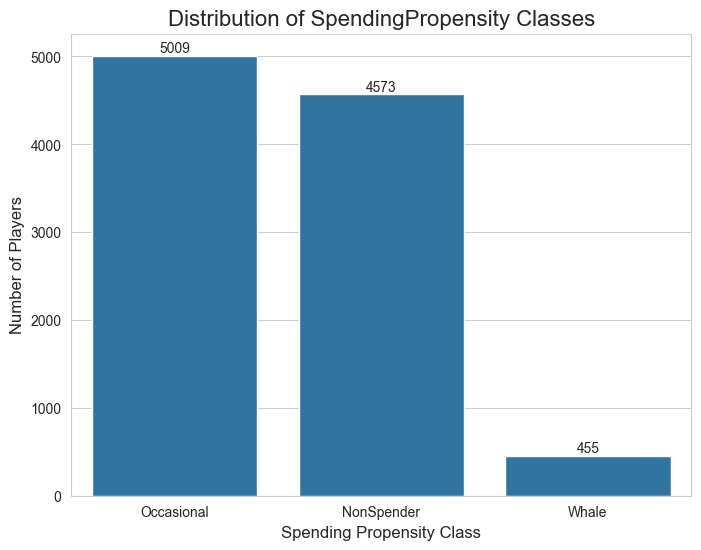

In [19]:
# Section 3: Futher exploration (with a focus on the problem - Spending Propensity)

# Displaying the distribution of SpendingPropensity:
print("SpendingPropensity Class Counts:\n\n", df['SpendingPropensity'].value_counts())
print("\nSpendingPropensity Class Percentages (1dp):\n\n", (df['SpendingPropensity'].value_counts(normalize=True) * 100).apply(lambda x: f"{x:.1f}%"))

# Creating a visualization:
plt.figure(figsize=(8, 6))
sns.countplot(x='SpendingPropensity', data=df, order=df['SpendingPropensity'].value_counts().index)

plt.title('Distribution of SpendingPropensity Classes', fontsize=16)
plt.xlabel('Spending Propensity Class', fontsize=12)
plt.ylabel('Number of Players', fontsize=12)

# Add value labels on top of each bar
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.0f')

plt.show()

## 3. Data Quality and Preprocessing

### Decision Point 1: Advanced Data Quality Strategy (Option C)

Implementation steps:
1. Remove duplicate rows
2. Remove noise (Age > 120)
3. Backfill AchievementsUnlocked missing values with 0
4. Impute remaining missing values:
   - Numeric: Median imputation
   - Categorical: Mode imputation

In [20]:
# Section 4: Checking data quality issues

# Displaying missing values: count and percentage
print("\n--- Missing Values ---")
missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df)) * 100
missing_info = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_percentages
})
# Displaying only columns with missing values, sorted
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)
print(missing_info.round(2))

# Checking for duplicates
print("\n--- Duplicates ---")
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# Checking for noise in Age column
print("\n--- Noise in Age Column ---")
print("Age descriptive statistics:\n", df['Age'].describe())
age_noise_count = df[df['Age'] > 120].shape[0]
print(f"Number of rows with Age > 120 (noise): {age_noise_count}")


--- Missing Values ---
                           Missing Count  Missing Percentage (%)
AvgSessionDurationMinutes            805                    8.02
AchievementsUnlocked                 606                    6.04
GameDifficulty                         6                    0.06
PlayerLevel                            5                    0.05
AvgPurchaseValue                       4                    0.04
SessionsPerWeek                        3                    0.03
Age                                    3                    0.03
Gender                                 3                    0.03
PurchaseCount                          3                    0.03
EngagementLevel                        3                    0.03
AvgPurchasesPerMonth                   2                    0.02
TotalSpend                             2                    0.02
PlayTimeHours                          1                    0.01
GameGenre                              1                    0.01
L

In [21]:
# Section 5: Implementing the data quality strategy (Option C - Advanced Preprocessing)

print("--- Data Quality Strategy (Option C) ---")
initial_rows = df.shape[0]
original_duplicates = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"Removed {original_duplicates} duplicate rows. Remaining rows: {df.shape[0]}")

# Removing noise (Age > 120)
original_age_noise = df[df['Age'] > 120].shape[0]
df = df[df['Age'] <= 120]
print(f"Removed {original_age_noise} rows with Age > 120. Remaining rows: {df.shape[0]}")

# Backfill AchievementsUnlocked missing values with 0
df['AchievementsUnlocked'] = df['AchievementsUnlocked'].fillna(0)
print("Backfilled missing 'AchievementsUnlocked' with 0.")

# Impute remaining missing values
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Imputing median values for numeric columns
for col in numeric_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

# Imputing median values for categoric columns
for col in categorical_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)

print("Imputed remaining numeric columns with median and categorical columns with mode.")

# Verify
print("\n--- Verification After Cleaning ---")
missing_after_cleaning = df.isnull().sum()
missing_after_cleaning_display = missing_after_cleaning[missing_after_cleaning > 0]
if missing_after_cleaning_display.empty:
    print("All missing values have been successfully handled.")
else:
    print("Remaining missing values:")
    print(missing_after_cleaning_display)

--- Data Quality Strategy (Option C) ---
Removed 24 duplicate rows. Remaining rows: 10013
Removed 73 rows with Age > 120. Remaining rows: 9937
Backfilled missing 'AchievementsUnlocked' with 0.
Imputed remaining numeric columns with median and categorical columns with mode.

--- Verification After Cleaning ---
All missing values have been successfully handled.



--- Cleaned Dataset Summary ---
Final Dataset Shape: (9937, 21)
No missing values remain in the dataset.

SpendingPropensity Class Counts (After Cleaning):
 SpendingPropensity
Occasional    4957
NonSpender    4529
Whale          451
Name: count, dtype: int64

SpendingPropensity Class Percentages (1dp After Cleaning):
 SpendingPropensity
Occasional    49.9%
NonSpender    45.6%
Whale          4.5%
Name: proportion, dtype: object


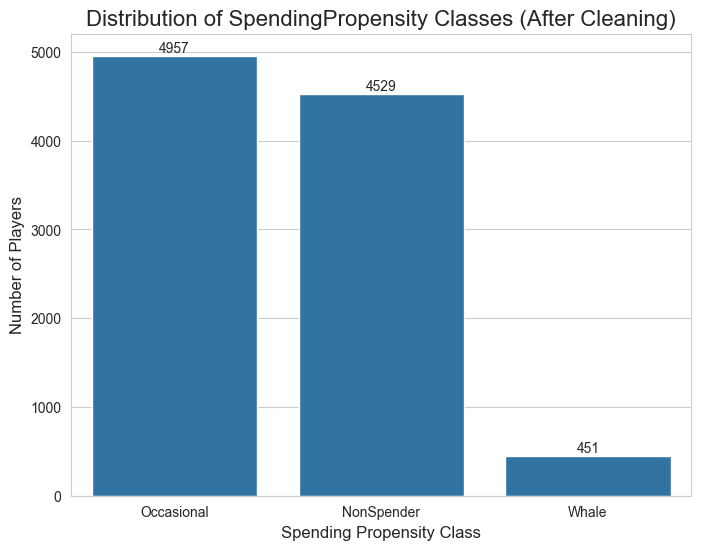

In [22]:
# Section 6: Display the final dataset shape after cleaning
print("\n--- Cleaned Dataset Summary ---")
print("Final Dataset Shape:", df.shape)

# Confirm no missing values remain
missing_after_cleaning = df.isnull().sum().sum()
if missing_after_cleaning == 0:
    print("No missing values remain in the dataset.")
else:
    print(f"{missing_after_cleaning} missing values still remain.")

# Showing SpendingPropensity distribution after cleaning
print("\nSpendingPropensity Class Counts (After Cleaning):\n", df['SpendingPropensity'].value_counts())
print("\nSpendingPropensity Class Percentages (1dp After Cleaning):\n", (df['SpendingPropensity'].value_counts(normalize=True) * 100).apply(lambda x: f"{x:.1f}%"))

# Visualizing the distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='SpendingPropensity', data=df, order=df['SpendingPropensity'].value_counts().index)
plt.title('Distribution of SpendingPropensity Classes (After Cleaning)', fontsize=16)
plt.xlabel('Spending Propensity Class', fontsize=12)
plt.ylabel('Number of Players', fontsize=12)
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.0f')
plt.show()

## 4. Feature Engineering and Selection

Focus on features related to SpendingPropensity prediction.

In [23]:
# Section 7: Selecting features to include

# Defining the list of features to be included based on EDA findings, relevant features for predicting SpendingPropensity
selected_features = [
    'Age', 'Gender', 'Location', 'GameGenre', 'GameDifficulty',
    'PlayTimeHours', 'SessionsPerWeek', 'AvgSessionDurationMinutes',
    'PlayerLevel', 'AchievementsUnlocked', 'EngagementLevel', 'DaysPlayed',
    'PlayerExpertise'
]

# separate features from target
columns_to_drop = [
    'SpendingPropensity',  
    'PurchaseCount',       
    'TotalSpend',          
    'AvgPurchasesPerMonth',
    'AvgPurchaseValue'     
]

X = df.drop(columns=columns_to_drop, axis=1)
y = df['SpendingPropensity']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Displaying the first few rows of X to verify the feature selection
display(X.head())
# Displaying the first few rows of y to verify the target variable
display(y.head())

Features shape: (9937, 16)
Target shape: (9937,)


,PlayerID,Age,Gender,Location,GameID,GameName,GameGenre,GameDifficulty,PlayTimeHours,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,DaysPlayed,PlayerExpertise
0,1,24.0,Male,USA,ACT_001,Battle Royale Extreme,Action,Medium,50.00,8.0,61.0,10.0,10.0,Medium,17.0,Intermediate
1,1,24.0,Male,USA,RPG_002,Mystic Realms Online,RPG,Medium,150.00,5.0,124.0,13.0,13.0,Medium,47.0,Intermediate
2,1,24.0,Male,USA,ACT_003,Street Fighter Ultimate,Action,Easy,131.66,14.0,53.0,26.0,29.0,Medium,73.0,Beginner
3,2,27.0,Male,Asia,STR_001,Empire Builder,Strategy,Easy,398.34,3.0,168.0,44.0,9.0,Medium,329.0,Beginner
4,3,27.0,Male,Europe,ACT_001,Battle Royale Extreme,Action,Hard,119.72,4.0,50.0,30.0,12.0,Low,232.0,Intermediate


0    Occasional
1    Occasional
2    Occasional
3    Occasional
4    NonSpender
Name: SpendingPropensity, dtype: object

In [24]:
# Section 8: Encoding categorical values

# Identifying categorical columns in X
categorical_cols_X = X.select_dtypes(include=['object']).columns

# Use One-Hot Encoding (pd.get_dummies) for categorical features:
X = pd.get_dummies(X, columns=categorical_cols_X, drop_first=True, dtype=int)

# Encoding target variable (y) using LabelEncoder:
label_encoder = LabelEncoder()

# Fitting and transform SpendingPropensity
y_encoded = label_encoder.fit_transform(y)

# Store the encoder for later reference (the 'label_encoder' object itself serves this purpose)

# Displaying the encoding mapping (0, 1, 2 correspond to which class)
print("\nLabel Encoding for SpendingPropensity:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name}: {i}")
    
# Shape of X after encoding
print("\nShape of X after One-Hot Encoding:", X.shape);

# First few rows of encoded X
print("\nFirst 5 rows of encoded X:");
display(X.head());

# Distribution of encoded y
print("\nDistribution of encoded y:");
print(pd.Series(y_encoded).value_counts())


Label Encoding for SpendingPropensity:
NonSpender: 0
Occasional: 1
Whale: 2

Shape of X after One-Hot Encoding: (9937, 36)

First 5 rows of encoded X:


,PlayerID,Age,PlayTimeHours,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,DaysPlayed,Gender_Male,Gender_Other,Location_Europe,Location_USA,GameID_ACT_002,GameID_ACT_003,GameID_RPG_001,GameID_RPG_002,GameID_RPG_003,GameID_STR_001,GameID_STR_002,GameID_STR_003,GameName_Chess Legends Online,GameName_Dragon's Quest,GameName_Dungeon Crawler Deluxe,GameName_Empire Builder,GameName_Mystic Realms Online,GameName_Street Fighter Ultimate,GameName_Tower Defense Masters,GameName_Zombie Apocalypse,GameGenre_RPG,GameGenre_Strategy,GameDifficulty_Hard,GameDifficulty_Medium,EngagementLevel_Low,EngagementLevel_Medium,PlayerExpertise_Expert,PlayerExpertise_Intermediate
0,1,24.0,50.00,8.0,61.0,10.0,10.0,17.0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1
1,1,24.0,150.00,5.0,124.0,13.0,13.0,47.0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0,1
2,1,24.0,131.66,14.0,53.0,26.0,29.0,73.0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
3,2,27.0,398.34,3.0,168.0,44.0,9.0,329.0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0
4,3,27.0,119.72,4.0,50.0,30.0,12.0,232.0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1



Distribution of encoded y:
1    4957
0    4529
2     451
Name: count, dtype: int64


## 5. Train-Test Split

Split data before applying SMOTE to prevent data leakage.

In [25]:
# Section 9: Spliting the data and verifying orginal class balance

# Splitting data into training and test sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Displaying class distribution in the training set
print("\nClass Distribution in Training Set:")
print((pd.Series(y_train).value_counts(normalize=True) * 100).apply(lambda x: f"{x:.1f}%"))

# Displaying class distribution in the test set
print("\nClass Distribution in Test Set:")
print((pd.Series(y_test).value_counts(normalize=True) * 100).apply(lambda x: f"{x:.1f}%"))

# Verify that stratification maintained the orginal ~45.6% / 49.9% / 4.5% proportions
print("\nVerification: Original vs. Training vs. Test set class proportions (should be similar):")
original_proportions = (pd.Series(y_encoded).value_counts(normalize=True) * 100).apply(lambda x: f"{x:.1f}%")
train_proportions = (pd.Series(y_train).value_counts(normalize=True) * 100).apply(lambda x: f"{x:.1f}%")
test_proportions = (pd.Series(y_test).value_counts(normalize=True) * 100).apply(lambda x: f"{x:.1f}%")

print("Original:  ", original_proportions.to_dict())
print("Training:  ", train_proportions.to_dict())
print("Test:      ", test_proportions.to_dict())

Training set size: 7949 samples
Test set size: 1988 samples

Class Distribution in Training Set:
1    49.9%
0    45.6%
2     4.5%
Name: proportion, dtype: object

Class Distribution in Test Set:
1    49.9%
0    45.6%
2     4.5%
Name: proportion, dtype: object

Verification: Original vs. Training vs. Test set class proportions (should be similar):
Original:   {1: '49.9%', 0: '45.6%', 2: '4.5%'}
Training:   {1: '49.9%', 0: '45.6%', 2: '4.5%'}
Test:       {1: '49.9%', 0: '45.6%', 2: '4.5%'}


## 6. Additional Preprocessing

### Decision Point 2: Feature Scaling and Class Imbalance Handling

- **StandardScaler**: Normalize features to have mean=0 and std=1
- **SMOTE**: Handle class imbalance (particularly the 4.5% Whale class)

In [26]:
# Section 10: Implementing feature scaling (StandardScalar)

# 1. Creating StandardScaler instance
scaler = StandardScaler()

# 2. Fit the scaler on X_train ONLY and transform X_train
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform X_test using the fitted scaler
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for easier inspection and to preserve column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Displaying the mean of scaled training features (should be close to 0)
print("\nMean of scaled training features (should be ~0):\n", X_train_scaled.mean().round(2))

# Displaying the standard deviation of scaled training features (should be ~1)
print("\nStandard deviation of scaled training features (should be ~1):\n", X_train_scaled.std().round(2))

# Displaying the first 5 rows of scaled X_train to verify transformation
print("\nFirst 5 rows of scaled X_train:\n")
display(X_train_scaled.head())


Mean of scaled training features (should be ~0):
 PlayerID                           -0.0
Age                                 0.0
PlayTimeHours                       0.0
SessionsPerWeek                     0.0
AvgSessionDurationMinutes          -0.0
PlayerLevel                        -0.0
AchievementsUnlocked                0.0
DaysPlayed                          0.0
Gender_Male                         0.0
Gender_Other                       -0.0
Location_Europe                     0.0
Location_USA                        0.0
GameID_ACT_002                      0.0
GameID_ACT_003                      0.0
GameID_RPG_001                     -0.0
GameID_RPG_002                      0.0
GameID_RPG_003                     -0.0
GameID_STR_001                     -0.0
GameID_STR_002                     -0.0
GameID_STR_003                     -0.0
GameName_Chess Legends Online      -0.0
GameName_Dragon's Quest            -0.0
GameName_Dungeon Crawler Deluxe    -0.0
GameName_Empire Builder      

,PlayerID,Age,PlayTimeHours,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,DaysPlayed,Gender_Male,Gender_Other,Location_Europe,Location_USA,GameID_ACT_002,GameID_ACT_003,GameID_RPG_001,GameID_RPG_002,GameID_RPG_003,GameID_STR_001,GameID_STR_002,GameID_STR_003,GameName_Chess Legends Online,GameName_Dragon's Quest,GameName_Dungeon Crawler Deluxe,GameName_Empire Builder,GameName_Mystic Realms Online,GameName_Street Fighter Ultimate,GameName_Tower Defense Masters,GameName_Zombie Apocalypse,GameGenre_RPG,GameGenre_Strategy,GameDifficulty_Hard,GameDifficulty_Medium,EngagementLevel_Low,EngagementLevel_Medium,PlayerExpertise_Expert,PlayerExpertise_Intermediate
4035,-0.332779,0.686063,0.560491,-1.027654,-0.122086,1.775587,-0.714668,0.991650,-1.229121,-0.130447,-0.736408,1.222373,-0.337997,-0.328208,-0.38,-0.450888,3.073348,-0.337303,-0.272909,-0.281852,-0.281852,-0.38,3.073348,-0.337303,-0.450888,-0.328208,-0.272909,-0.337997,1.248036,-0.569748,-0.573815,1.239180,-0.660404,0.816368,-0.365552,-0.683679
7250,0.760770,1.785512,-0.821058,-1.326812,0.810255,-1.005890,-0.849211,-0.636074,0.813589,-0.130447,-0.736408,-0.818081,-0.337997,-0.328208,-0.38,-0.450888,-0.325378,-0.337303,-0.272909,3.547962,3.547962,-0.38,-0.325378,-0.337303,-0.450888,-0.328208,-0.272909,-0.337997,-0.801259,1.755163,-0.573815,1.239180,1.514224,-1.224937,-0.365552,-0.683679
2206,-0.968017,0.197419,-0.821058,-0.429337,-1.448083,-1.046201,-0.983754,-0.696585,-1.229121,-0.130447,-0.736408,-0.818081,-0.337997,3.046853,-0.38,-0.450888,-0.325378,-0.337303,-0.272909,-0.281852,-0.281852,-0.38,-0.325378,-0.337303,-0.450888,3.046853,-0.272909,-0.337997,-0.801259,-0.569748,-0.573815,-0.806985,1.514224,-1.224937,-0.365552,-0.683679
935,-1.407675,-1.268514,-0.255994,-0.429337,0.789536,-0.804334,-0.669821,-0.291166,0.813589,-0.130447,-0.736408,-0.818081,-0.337997,-0.328208,-0.38,-0.450888,-0.325378,2.964694,-0.272909,-0.281852,-0.281852,-0.38,-0.325378,2.964694,-0.450888,-0.328208,-0.272909,-0.337997,-0.801259,1.755163,-0.573815,1.239180,-0.660404,0.816368,-0.365552,-0.683679
9167,1.437576,0.563902,0.305040,-0.429337,1.183192,-0.360910,0.541066,0.011385,0.813589,-0.130447,-0.736408,-0.818081,-0.337997,-0.328208,-0.38,-0.450888,-0.325378,2.964694,-0.272909,-0.281852,-0.281852,-0.38,-0.325378,2.964694,-0.450888,-0.328208,-0.272909,-0.337997,-0.801259,1.755163,-0.573815,1.239180,-0.660404,0.816368,-0.365552,-0.683679


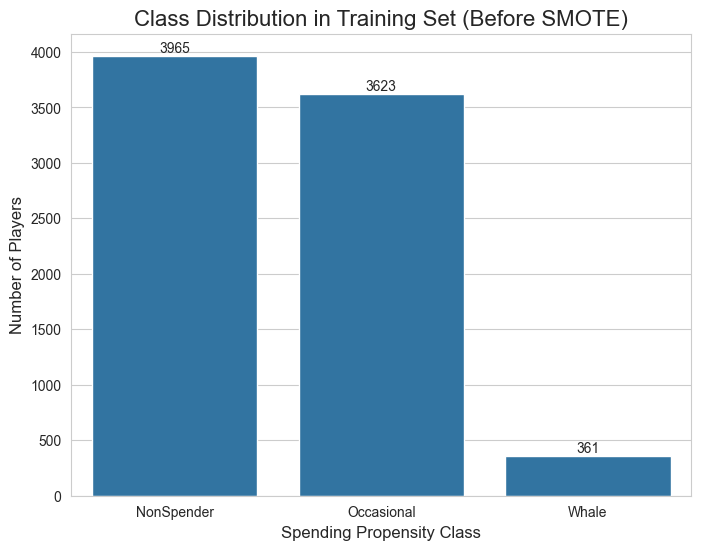

In [27]:
# Code section 11: Verify class imbalance before applying SMOTE to data

# Creating a bar plot to visualize the class distribution in y_train
plt.figure(figsize=(8, 6))
sns.countplot(x=y_train, order=pd.Series(y_train).value_counts().index)

plt.title('Class Distribution in Training Set (Before SMOTE)', fontsize=16)
plt.xlabel('Spending Propensity Class', fontsize=12)
plt.ylabel('Number of Players', fontsize=12)

# Map numerical labels back to original class names for clarity on x-axis ticks
class_labels = [label_encoder.inverse_transform([i])[0] for i in sorted(pd.Series(y_train).unique())]
plt.xticks(ticks=sorted(pd.Series(y_train).unique()), labels=class_labels)

# Add value labels on top of each bar for count visibility
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.0f')

# Displaying the plot
plt.show()

# 7. Model Training and Evaluation
## Decision Point 3: My Chosen Three ML Models

* Model 1: Logistic Regression (Linear, interpretable)
* Model 2: Support Vector Machine - RBF kernel (Non-linear, performance-oriented)
* Model 3: Random Forest (Ensemble, robust)

## Decision Point 5: Hyperparameter Optimization
Using GridSearchCV with 3-fold cross-validation to optimize model parameters. Scoring metric: f1_macro to balance performance across all spending classes (NonSpender, Occasional, Whale).

## Decision Point 6: 5-Fold Cross-Validation with Stratification
SMOTE will be applied INSIDE each fold to prevent data leakage.

In [28]:
# Code section 12: Defining each model + storing it in a dictionary

# Defining Logistic Regression model
logistic_regression_model = LogisticRegression(max_iter=1000, random_state=7)

# Defining Support Vector Machine (SVC) model with RBF kernel
svm_model = SVC(kernel='rbf', random_state=7, probability=True)

# Defining Random Forest Classifier model
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=7)

# Making a dictionary to store the defined models
models = {
    'Logistic Regression': logistic_regression_model,
    'SVM': svm_model,
    'Random Forest': random_forest_model
}

# Displaying my models dictionary to confirm
print("Defined Models:")
for name, model in models.items():
    print(f"- {name}: {model}")

Defined Models:
- Logistic Regression: LogisticRegression(max_iter=1000, random_state=7)
- SVM: SVC(probability=True, random_state=7)
- Random Forest: RandomForestClassifier(random_state=7)


In [29]:
# Code section 13: Defining hyperparameter grids for optimisation

# 1. Logistic Regression parameter grid:
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['lbfgs', 'saga'],
    'classifier__class_weight': [None, 'balanced'],
    'classifier__max_iter': [1000]
}

# 2. SVM parameter grid:
param_grid_svm = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'classifier__class_weight': [None, 'balanced'],
    'classifier__kernel': ['rbf']
}

# 3. Random Forest parameter grid:
param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, 30],
    'classifier__min_samples_split': [5, 10],
    'classifier__class_weight': [None, 'balanced']
}

# Store all grids in a dictionary:
param_grids = {
    'Logistic Regression': param_grid_lr,
    'SVM': param_grid_svm,
    'Random Forest': param_grid_rf
}

# Displaying the parameter grids to verify
print("Defined Hyperparameter Grids:")
for name, grid in param_grids.items():
    total_combinations = 1
    for param_list in grid.values():
        total_combinations *= len(param_list)
    print(f"- {name}: {grid} (Total combinations: {total_combinations})")

Defined Hyperparameter Grids:
- Logistic Regression: {'classifier__C': [0.01, 0.1, 1, 10, 100], 'classifier__solver': ['lbfgs', 'saga'], 'classifier__class_weight': [None, 'balanced'], 'classifier__max_iter': [1000]} (Total combinations: 20)
- SVM: {'classifier__C': [0.1, 1, 10, 100], 'classifier__gamma': ['scale', 'auto', 0.001, 0.01, 0.1], 'classifier__class_weight': [None, 'balanced'], 'classifier__kernel': ['rbf']} (Total combinations: 40)
- Random Forest: {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [10, 20, 30], 'classifier__min_samples_split': [5, 10], 'classifier__class_weight': [None, 'balanced']} (Total combinations: 24)


In [30]:
# Section 14: Optimising hyperparameters for GridSearch

optimized_pipelines = {}

optimization_results = []

# Setting up the cross-validation strategy for GridSearchCV
grid_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# For each of my models and its corresponding parameter grid:
print("Starting Hyperparameter Optimization (this may take several minutes)...")
for name, model in models.items():
    print(f"\nOptimizing {name}... (this may take several minutes)")
    start_time = time.time()

    # 1. Creating the base pipeline (SMOTE + classifier)
    pipeline = Pipeline([
        ('smote', SMOTE(random_state=7, sampling_strategy='auto')),
        ('classifier', model)
    ])

    # 2. Initialize GridSearchCV
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        cv=grid_cv,
        scoring='f1_macro',
        n_jobs=-1, 
        verbose=2, 
        return_train_score=False
    )

    # 3. Fit GridSearchCV on X_train_scaled and y_train
    grid_search.fit(X_train_scaled, y_train)

    # 4. After fitting, extract and display best parameters and score
    end_time = time.time()
    print(f"Optimization for {name} complete in {end_time - start_time:.2f} seconds.")
    print(f"Best parameters for {name}: {grid_search.best_params_}")
    print(f"Best cross-validation F1-macro score for {name}: {grid_search.best_score_:.4f}")

    # 5. Store the best estimator
    optimized_pipelines[name] = grid_search.best_estimator_

    # Store results for summary table
    optimization_results.append({
        'Model': name,
        'Best Parameters': grid_search.best_params_,
        'Best CV F1-Score': grid_search.best_score_
    })

# Making a summary DataFrame showing best parameters for each model
optimization_summary_df = pd.DataFrame(optimization_results)
print("\n--- Hyperparameter Optimization Summary ---")
display(optimization_summary_df.set_index('Model'))

Starting Hyperparameter Optimization (this may take several minutes)...

Optimizing Logistic Regression... (this may take several minutes)
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Optimization for Logistic Regression complete in 6.88 seconds.
Best parameters for Logistic Regression: {'classifier__C': 1, 'classifier__class_weight': None, 'classifier__max_iter': 1000, 'classifier__solver': 'saga'}
Best cross-validation F1-macro score for Logistic Regression: 0.6606

Optimizing SVM... (this may take several minutes)
Fitting 3 folds for each of 40 candidates, totalling 120 fits
Optimization for SVM complete in 91.91 seconds.
Best parameters for SVM: {'classifier__C': 100, 'classifier__class_weight': None, 'classifier__gamma': 0.001, 'classifier__kernel': 'rbf'}
Best cross-validation F1-macro score for SVM: 0.6640

Optimizing Random Forest... (this may take several minutes)
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Optimization for Random Forest comple

,Best Parameters,Best CV F1-Score
Model,,
Logistic Regression,"{'classifier__C': 1, 'classifier__class_weight...",0.660643
SVM,"{'classifier__C': 100, 'classifier__class_weig...",0.664037
Random Forest,"{'classifier__class_weight': None, 'classifier...",0.680040


In [31]:
# Section 15: Documenting parameter changes

print("\n--- Documenting Hyperparameter Changes ---")

def get_default_params(model_name):
    """Returns a dictionary of default parameters for a given model type."""
    if model_name == 'Logistic Regression':
        default_model = LogisticRegression(max_iter=1000, random_state=7)
        return {
            'C': default_model.C,
            'solver': default_model.solver,
            'class_weight': default_model.class_weight
        }
    elif model_name == 'SVM':
        default_model = SVC(kernel='rbf', random_state=7, probability=True)
        return {
            'C': default_model.C,
            'gamma': default_model.gamma,
            'class_weight': default_model.class_weight,
            'kernel': default_model.kernel
        }
    elif model_name == 'Random Forest':
        default_model = RandomForestClassifier(n_estimators=100, random_state=7)
        return {
            'n_estimators': default_model.n_estimators,
            'max_depth': default_model.max_depth,
            'min_samples_split': default_model.min_samples_split,
            'class_weight': default_model.class_weight
        }
    return {}

# Initialize a list to store the comparison results
comparison_data = []

# Ensure optimization_results is populated from the previous cell (Section 14)
if not optimization_results:
    print("Error: 'optimization_results' is empty. Please run 'Section 14: Optimising hyperparameters for GridSearch' first.")
else:
    for result in optimization_results:
        model_name = result['Model']
        optimized_params = result['Best Parameters']
        default_params = get_default_params(model_name)

        print(f"\n### {model_name}:")
        print(f"Default parameters: {default_params}")

        current_model_changes = []
        for param, opt_val in optimized_params.items():
            # Removing the 'classifier__' prefix to match default_params keys
            clean_param = param.replace('classifier__', '')

            # Retrieve the default value for comparison
            default_val = default_params.get(clean_param, 'N/A')

            # Checking if the parameter value has changed
            if default_val != opt_val:
                change_description = "Changed"
                if isinstance(default_val, (int, float)) and isinstance(opt_val, (int, float)):
                    if opt_val > default_val: change_description = "Increased"
                    elif opt_val < default_val: change_description = "Decreased"
                elif default_val is None and opt_val is not None: change_description = "Added (from None)"
                elif default_val is not None and opt_val is None: change_description = "Removed (to None)"

                print(f"- {clean_param}: {default_val} -> {opt_val} ({change_description})")
                comparison_data.append({
                    'Model': model_name,
                    'Parameter': clean_param,
                    'Default Value': default_val,
                    'Optimized Value': opt_val,
                    'Change': change_description
                })
            # Also include parameters that were in the grid but didn't change from default

    # Displaying a summary DataFrame of all changes
    if comparison_data:
        changes_df = pd.DataFrame(comparison_data)
        print("\n--- Summary of Optimized Parameter Changes ---")
        display(changes_df)
    else:
        print("No significant parameter changes observed from default values after optimization (or parameters were not in the grid).")



--- Documenting Hyperparameter Changes ---

### Logistic Regression:
Default parameters: {'C': 1.0, 'solver': 'lbfgs', 'class_weight': None}
- max_iter: N/A -> 1000 (Changed)
- solver: lbfgs -> saga (Changed)

### SVM:
Default parameters: {'C': 1.0, 'gamma': 'scale', 'class_weight': None, 'kernel': 'rbf'}
- C: 1.0 -> 100 (Increased)
- gamma: scale -> 0.001 (Changed)

### Random Forest:
Default parameters: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'class_weight': None}
- max_depth: None -> 20 (Added (from None))
- min_samples_split: 2 -> 5 (Increased)

--- Summary of Optimized Parameter Changes ---


,Model,Parameter,Default Value,Optimized Value,Change
0,Logistic Regression,max_iter,N/A,1000,Changed
1,Logistic Regression,solver,lbfgs,saga,Changed
2,SVM,C,1.0,100,Increased
3,SVM,gamma,scale,0.001,Changed
4,Random Forest,max_depth,None,20,Added (from None)
5,Random Forest,min_samples_split,2,5,Increased


In [32]:
# Section 13: Using the optimized pipelines from GridSearch

# Pipeline for Logistic Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=7)),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=7,
    ))
])

# Pipeline for SVM with RBF kernel
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),  
    ('smote', SMOTE(random_state=7)),  
    ('classifier', SVC(
        kernel='rbf',  
        random_state=7, 
        probability=True  
    ))
])

# Pipeline for Random Forest
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),  
    ('smote', SMOTE(random_state=7)), 
    ('classifier', RandomForestClassifier(
        n_estimators=100,  
        random_state=7,  
        n_jobs=-1  
    ))
])

# Store pipelines in a dictionary for easy iteration
pipelines = {
    'Logistic Regression': lr_pipeline,
    'SVM (RBF)': svm_pipeline,
    'Random Forest': rf_pipeline
}

print("Optimized pipelines created with StandardScaler + SMOTE + Classifier")
print(f"Number of models: {len(pipelines)}")
print(f"Models: {list(pipelines.keys())}")

Optimized pipelines created with StandardScaler + SMOTE + Classifier
Number of models: 3
Models: ['Logistic Regression', 'SVM (RBF)', 'Random Forest']


In [33]:
# Section 14: Setting up cross-validation strategy

# Setting up stratified k-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,  
    shuffle=True,  
    random_state=7  
)

# Defining scoring metrics for cross-validation
scoring = {
    'accuracy': 'accuracy',  
    'precision_weighted': 'precision_weighted',  
    'recall_weighted': 'recall_weighted',  
    'f1_weighted': 'f1_weighted'  
}

print("Cross-validation strategy defined:")
print(f"  - Method: {cv.n_splits}-Fold Stratified Cross-Validation")
print(f"  - Shuffle: {cv.shuffle}")
print(f"  - Random state: {cv.random_state}")
print(f"  - Metrics: {list(scoring.keys())}")

Cross-validation strategy defined:
  - Method: 5-Fold Stratified Cross-Validation
  - Shuffle: True
  - Random state: 7
  - Metrics: ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']


In [34]:
# Section 15: Running cross-validation with optimized models

# Running cross-validation for each pipeline

# Dictionary to store results
cv_results = {}

# Looping through each pipeline
for model_name, pipeline in pipelines.items():
    print(f"\n{model_name}:")
    print("-" * 70)
    
    # Tracking the start time for performance tracking
    start_time = time.time()
    
    # Running cross-validation with multiple scoring metrics
    scores = cross_validate(
        pipeline,  
        X_train,  
        y_train,  
        cv=cv,  
        scoring=scoring,  
        n_jobs=-1,  
        return_train_score=False  
    )
    
    # Calculating elapsed time
    elapsed_time = time.time() - start_time
    
    # Store results for this model
    cv_results[model_name] = {
        'accuracy': scores['test_accuracy'],  
        'precision': scores['test_precision_weighted'],  
        'recall': scores['test_recall_weighted'],  
        'f1_score': scores['test_f1_weighted'], 
        'time': elapsed_time  
    }
    
    # Displaying results for this model
    print(f"  Accuracy:  {scores['test_accuracy'].mean():.4f} (±{scores['test_accuracy'].std():.4f})")
    print(f"  Precision: {scores['test_precision_weighted'].mean():.4f} (±{scores['test_precision_weighted'].std():.4f})")
    print(f"  Recall:    {scores['test_recall_weighted'].mean():.4f} (±{scores['test_recall_weighted'].std():.4f})")
    print(f"  F1-Score:  {scores['test_f1_weighted'].mean():.4f} (±{scores['test_f1_weighted'].std():.4f})")
    print(f"  Time:      {elapsed_time:.2f} seconds")


Logistic Regression:
----------------------------------------------------------------------
  Accuracy:  0.7230 (±0.0064)
  Precision: 0.7509 (±0.0104)
  Recall:    0.7230 (±0.0064)
  F1-Score:  0.7297 (±0.0065)
  Time:      0.17 seconds

SVM (RBF):
----------------------------------------------------------------------
  Accuracy:  0.7339 (±0.0063)
  Precision: 0.7496 (±0.0093)
  Recall:    0.7339 (±0.0063)
  F1-Score:  0.7378 (±0.0067)
  Time:      12.60 seconds

Random Forest:
----------------------------------------------------------------------
  Accuracy:  0.7515 (±0.0050)
  Precision: 0.7523 (±0.0051)
  Recall:    0.7515 (±0.0050)
  F1-Score:  0.7518 (±0.0049)
  Time:      0.57 seconds


In [35]:
# Section 16: Creating a summary table of cross-validation results

# Setting up data for DataFrame
summary_data = []

# Extracting mean and std for each model and metric
for model_name, results in cv_results.items():
    summary_data.append({
        'Model': model_name,
        'Accuracy (Mean)': results['accuracy'].mean(),
        'Accuracy (Std)': results['accuracy'].std(),
        'Precision (Mean)': results['precision'].mean(),
        'Precision (Std)': results['precision'].std(),
        'Recall (Mean)': results['recall'].mean(),
        'Recall (Std)': results['recall'].std(),
        'F1-Score (Mean)': results['f1_score'].mean(),
        'F1-Score (Std)': results['f1_score'].std(),
        'Training Time (s)': results['time']
    })

# Making a DataFrame
cv_summary = pd.DataFrame(summary_data)

# Sort by F1-Score (descending) to see best model first
cv_summary = cv_summary.sort_values('F1-Score (Mean)', ascending=False)

# Displaying the summary table
print("\nCross-Validation Results Summary:")
print("=" * 100)
print(cv_summary.to_string(index=False))
print("=" * 100)

# Identifying best model based on F1-Score
best_model = cv_summary.iloc[0]['Model']
best_f1 = cv_summary.iloc[0]['F1-Score (Mean)']
print(f"\nBest Model (by F1-Score): {best_model} ({best_f1:.4f})")


Cross-Validation Results Summary:
              Model  Accuracy (Mean)  Accuracy (Std)  Precision (Mean)  Precision (Std)  Recall (Mean)  Recall (Std)  F1-Score (Mean)  F1-Score (Std)  Training Time (s)
      Random Forest         0.751542        0.004957          0.752312         0.005068       0.751542      0.004957         0.751754        0.004888           0.571199
          SVM (RBF)         0.733929        0.006334          0.749551         0.009279       0.733929      0.006334         0.737829        0.006681          12.601772
Logistic Regression         0.722984        0.006431          0.750909         0.010375       0.722984      0.006431         0.729750        0.006482           0.170133

Best Model (by F1-Score): Random Forest (0.7518)


## 8. Final Model Training on Full Training Set

In [36]:
# Section 17: Training final models on the full training set

# Dictionary to store my fitted pipelines
fitted_pipelines = {}

# Training each pipeline
for model_name, pipeline in pipelines.items():
    print(f"\nTraining {model_name}...")
    
    # Tracking the start time
    start_time = time.time()
    
    # Fitting the pipeline on all training data
    # SMOTE will balance the training data before fitting the classifier
    pipeline.fit(X_train, y_train)
    
    # Calculating training time
    elapsed_time = time.time() - start_time
    
    # Store the fitted pipeline
    fitted_pipelines[model_name] = pipeline
    
    print(f"Trained in {elapsed_time:.2f} seconds")


Training Logistic Regression...
Trained in 0.08 seconds

Training SVM (RBF)...
Trained in 8.88 seconds

Training Random Forest...
Trained in 0.23 seconds


## 9. Test Set Evaluation

### Decision Point 7: Advanced Metrics
Evaluate on test set using:
- Accuracy, Precision, Recall, F1-Score
- Confusion Matrix
- Detailed Classification Report

In [37]:
# Section 18: Making predictions on the test set

# Dictionary to store predictions
predictions = {}

# Making predictions with each model
for model_name, pipeline in fitted_pipelines.items():
    print(f"\n{model_name}:")
    
    # Making predictions
    y_pred = pipeline.predict(X_test)
    
    # Store predictions
    predictions[model_name] = y_pred
    
    # Showing prediction distribution
    unique, counts = np.unique(y_pred, return_counts=True)
    print(f"  Prediction distribution:")
    for label, count in zip(unique, counts):
        print(f"    {label}: {count} ({count/len(y_pred)*100:.1f}%)")


Logistic Regression:
  Prediction distribution:
    0: 923 (46.4%)
    1: 831 (41.8%)
    2: 234 (11.8%)

SVM (RBF):
  Prediction distribution:
    0: 937 (47.1%)
    1: 865 (43.5%)
    2: 186 (9.4%)

Random Forest:
  Prediction distribution:
    0: 910 (45.8%)
    1: 982 (49.4%)
    2: 96 (4.8%)


In [38]:
# Section 19: Calculating test set performance metrics

# Dictionary to store the test results
test_results = {}

# Working out the metrics for each model
for model_name, y_pred in predictions.items():
    print(f"\n{model_name}:")
    print("-" * 70)
    
    # Working out the metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # Store results
    test_results[model_name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'predictions': y_pred
    }
    
    # Displaying results
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")


Logistic Regression:
----------------------------------------------------------------------
  Accuracy:  0.7248
  Precision: 0.7571
  Recall:    0.7248
  F1-Score:  0.7330

SVM (RBF):
----------------------------------------------------------------------
  Accuracy:  0.7339
  Precision: 0.7542
  Recall:    0.7339
  F1-Score:  0.7394

Random Forest:
----------------------------------------------------------------------
  Accuracy:  0.7525
  Precision: 0.7533
  Recall:    0.7525
  F1-Score:  0.7529


In [39]:
# Section 20: Creating a summary table of test results

# Setting up data for DataFrame
test_summary_data = []

for model_name, results in test_results.items():
    test_summary_data.append({
        'Model': model_name,
        'Accuracy': results['accuracy'],
        'Precision': results['precision'],
        'Recall': results['recall'],
        'F1-Score': results['f1_score']
    })

# Making a DataFrame
test_summary = pd.DataFrame(test_summary_data)

# Sort by F1-Score (descending)
test_summary = test_summary.sort_values('F1-Score', ascending=False)

# Displaying the summary table
print("\nTest Set Results Summary:")
print("=" * 100)
print(test_summary.to_string(index=False))
print("=" * 100)

# Identifying best model on test set
best_test_model = test_summary.iloc[0]['Model']
best_test_f1 = test_summary.iloc[0]['F1-Score']
print(f"\nBest Model on Test Set (by F1-Score): {best_test_model} ({best_test_f1:.4f})")


Test Set Results Summary:
              Model  Accuracy  Precision   Recall  F1-Score
      Random Forest  0.752515   0.753326 0.752515  0.752886
          SVM (RBF)  0.733903   0.754161 0.733903  0.739363
Logistic Regression  0.724849   0.757065 0.724849  0.733021

Best Model on Test Set (by F1-Score): Random Forest (0.7529)


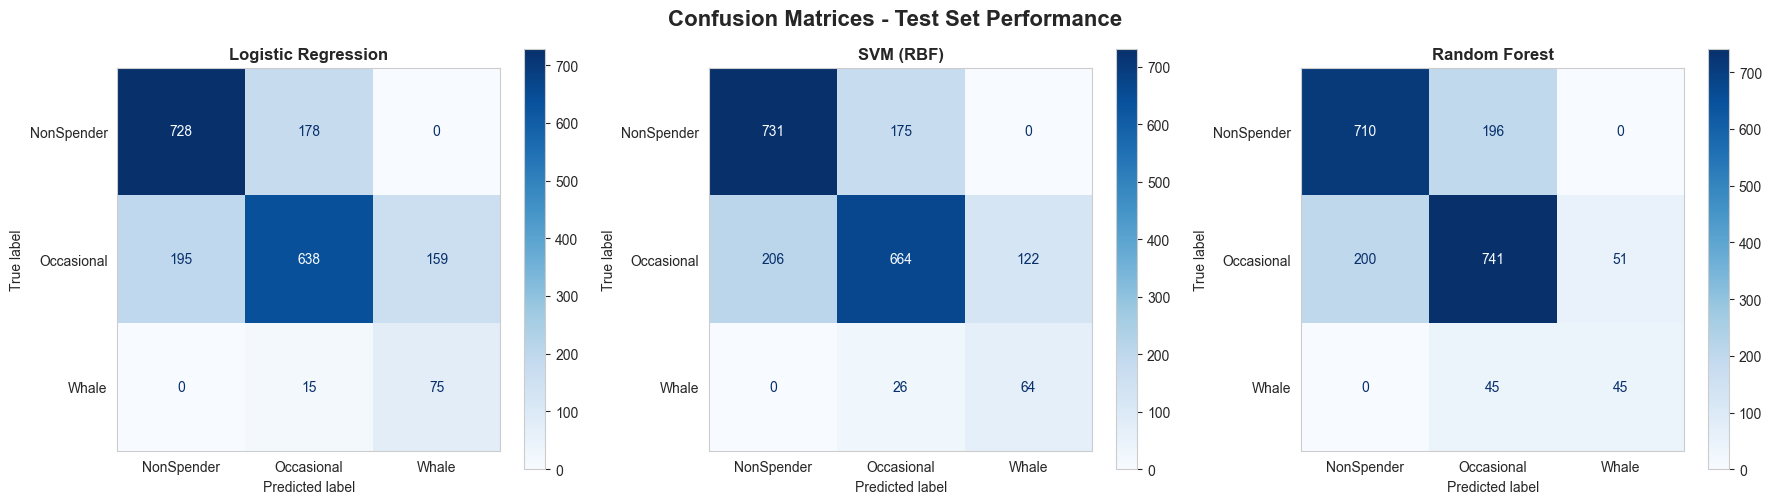

In [40]:
# Section 21: Generating confusion matrices for each model

# Setting up a figure with subplots for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices - Test Set Performance', fontsize=16, fontweight='bold')

# Creating confusion matrix for each model
for idx, (model_name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    
    # Making a visualization
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_  # Use actual class names
    )
    
    # Plot on appropriate subplot
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=True)
    axes[idx].set_title(f'{model_name}', fontweight='bold')
    axes[idx].grid(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [41]:
# Section 22: Detailed classification reports per class

# Creating a report for each model
for model_name, y_pred in predictions.items():
    print(f"\n{model_name}:")
    print("-" * 100)
    
    report = classification_report(
        y_test,  
        y_pred, 
        target_names=label_encoder.classes_,  
        zero_division=0 
    )
    
    print(report)


Logistic Regression:
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

  NonSpender       0.79      0.80      0.80       906
  Occasional       0.77      0.64      0.70       992
       Whale       0.32      0.83      0.46        90

    accuracy                           0.72      1988
   macro avg       0.63      0.76      0.65      1988
weighted avg       0.76      0.72      0.73      1988


SVM (RBF):
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

  NonSpender       0.78      0.81      0.79       906
  Occasional       0.77      0.67      0.72       992
       Whale       0.34      0.71      0.46        90

    accuracy                           0.73      1988
   macro avg       0.63      0.73      0.66      1988
weighted avg       0.75      0.73      0.74      1988


R

## 10. Additional Analysis for Task 2.3

Generate visualizations to support critical evaluation in Task 2.3.

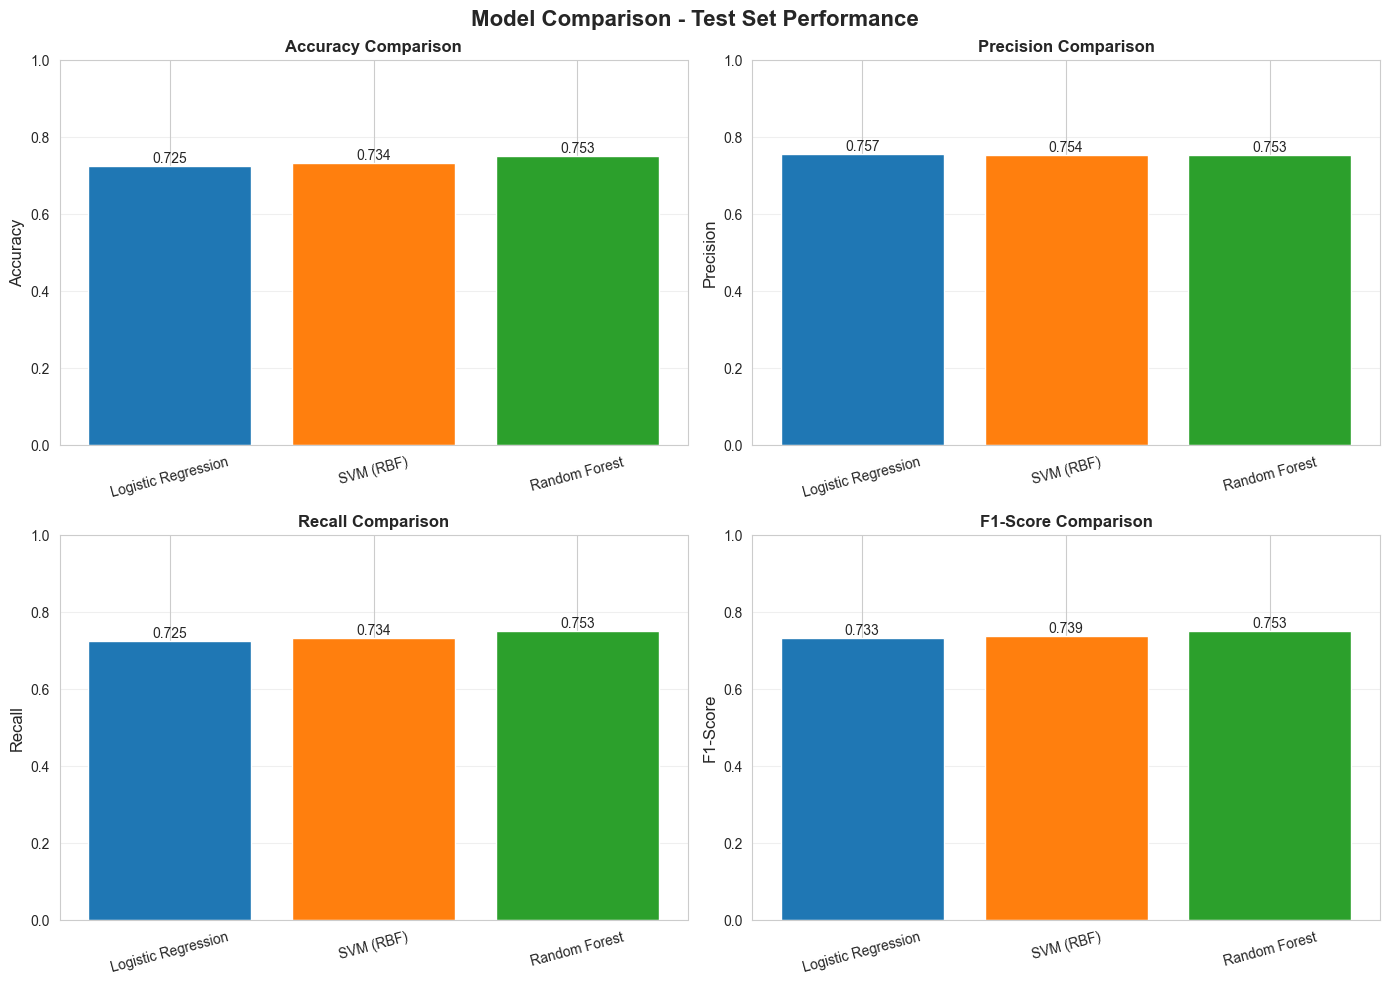

In [42]:
# Section 23: Visualizing model performance comparisons

# Setting up data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
models = list(test_results.keys())

# Pulling out the metric values for each model
metric_values = {metric: [] for metric in metrics}
for model_name in models:
    metric_values['Accuracy'].append(test_results[model_name]['accuracy'])
    metric_values['Precision'].append(test_results[model_name]['precision'])
    metric_values['Recall'].append(test_results[model_name]['recall'])
    metric_values['F1-Score'].append(test_results[model_name]['f1_score'])

# Creating subplots for each metric
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Comparison - Test Set Performance', fontsize=16, fontweight='bold')

# Flatten axes array for easier iteration
axes = axes.flatten()

# Plot each metric
for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # Creating bar plot
    bars = ax.bar(models, metric_values[metric], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    
    # Customize plot
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'{metric} Comparison', fontweight='bold')
    ax.set_ylim([0, 1.0])
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10)
    
    # Rotate x-axis labels if needed
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [43]:
# Section 24: Analyzing performance on each class

print("\nPer-Class Performance Analysis:")
print("=" * 100)

# Get class names
classes = label_encoder.classes_

# For each of my models, extract per-class metrics
for model_name, y_pred in predictions.items():
    print(f"\n{model_name}:")
    print("-" * 100)
    
    # Calculating per-class metrics (without averaging)
    precision_per_class = precision_score(y_test, y_pred, average=None, zero_division=0)
    recall_per_class = recall_score(y_test, y_pred, average=None, zero_division=0)
    f1_per_class = f1_score(y_test, y_pred, average=None, zero_division=0)
    
    # Making a DataFrame for better visualization
    per_class_df = pd.DataFrame({
        'Class': classes,
        'Precision': precision_per_class,
        'Recall': recall_per_class,
        'F1-Score': f1_per_class
    })
    
    print(per_class_df.to_string(index=False))
    print()


Per-Class Performance Analysis:

Logistic Regression:
----------------------------------------------------------------------------------------------------
     Class  Precision   Recall  F1-Score
NonSpender   0.788732 0.803532  0.796063
Occasional   0.767750 0.643145  0.699945
     Whale   0.320513 0.833333  0.462963


SVM (RBF):
----------------------------------------------------------------------------------------------------
     Class  Precision   Recall  F1-Score
NonSpender   0.780149 0.806843  0.793272
Occasional   0.767630 0.669355  0.715132
     Whale   0.344086 0.711111  0.463768


Random Forest:
----------------------------------------------------------------------------------------------------
     Class  Precision   Recall  F1-Score
NonSpender   0.780220 0.783664  0.781938
Occasional   0.754582 0.746976  0.750760
     Whale   0.468750 0.500000  0.483871




Extracting Feature Importance from Random Forest...

Top 15 Most Important Features:
                      Feature  Importance
                PlayTimeHours    0.137921
       EngagementLevel_Medium    0.086769
                   DaysPlayed    0.084694
                          Age    0.072458
          EngagementLevel_Low    0.065299
         AchievementsUnlocked    0.064902
                  PlayerLevel    0.062139
              SessionsPerWeek    0.060268
                     PlayerID    0.052186
    AvgSessionDurationMinutes    0.051645
              Location_Europe    0.045108
GameName_Mystic Realms Online    0.028319
                 Location_USA    0.024554
               GameID_RPG_002    0.023287
           GameGenre_Strategy    0.014164


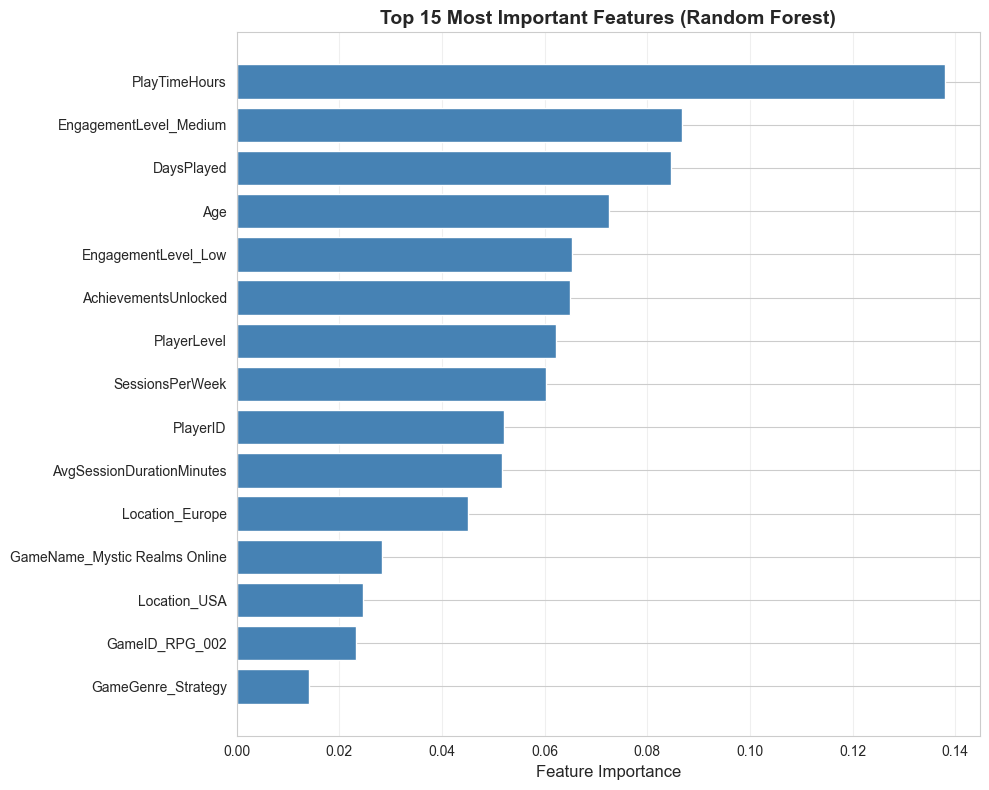

In [44]:
# Section 25: Extracting feature importance from Random Forest

print("\nExtracting Feature Importance from Random Forest...")

# Getting the Random Forest pipeline
rf_pipeline = fitted_pipelines['Random Forest']

# Getting the classifier from the pipeline (last step)
rf_classifier = rf_pipeline.named_steps['classifier']

# Get feature importances
feature_importances = rf_classifier.feature_importances_

# Making a DataFrame with feature names and importances
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort by importance (descending)
importance_df = importance_df.sort_values('Importance', ascending=False)

# Displaying top 15 features
print("\nTop 15 Most Important Features:")
print("=" * 60)
print(importance_df.head(15).to_string(index=False))
print("=" * 60)

# Making a visualization
plt.figure(figsize=(10, 8))

# Plot top 15 features
top_15 = importance_df.head(15)
plt.barh(range(len(top_15)), top_15['Importance'], color='steelblue')
plt.yticks(range(len(top_15)), top_15['Feature'])
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top 15 Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Highest importance at top
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


Verifying SMOTE Effect on Training Data...

Original Training Set Distribution (Before SMOTE):
  0: 3623 (45.6%)
  1: 3965 (49.9%)
  2: 361 (4.5%)

After SMOTE Balancing:
  0: 3965 (33.3%)
  1: 3965 (33.3%)
  2: 3965 (33.3%)


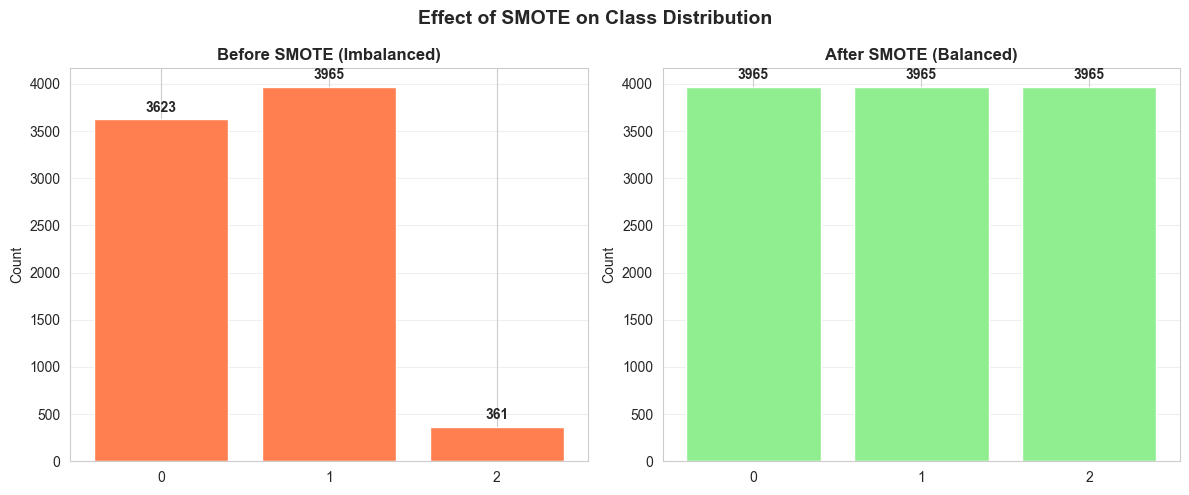

In [45]:
# Section 26: Verifying how SMOTE balanced the training data

print("\nVerifying SMOTE Effect on Training Data...")
print("=" * 70)

# Get original class distribution (before SMOTE)
original_dist = pd.Series(y_train).value_counts().sort_index()

print("\nOriginal Training Set Distribution (Before SMOTE):")
for class_name, count in original_dist.items():
    percentage = (count / len(y_train)) * 100
    print(f"  {class_name}: {count} ({percentage:.1f}%)")

# Applying SMOTE manually to show effect
smote = SMOTE(random_state=7)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Get class distribution after SMOTE
smote_dist = pd.Series(y_train_resampled).value_counts().sort_index()

print("\nAfter SMOTE Balancing:")
for class_name, count in smote_dist.items():
    percentage = (count / len(y_train_resampled)) * 100
    print(f"  {class_name}: {count} ({percentage:.1f}%)")

# Making a visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Effect of SMOTE on Class Distribution', fontsize=14, fontweight='bold')

# Plot original distribution
ax1.bar(range(len(original_dist)), original_dist.values, color='coral')
ax1.set_xticks(range(len(original_dist)))
ax1.set_xticklabels(original_dist.index, rotation=0)
ax1.set_ylabel('Count')
ax1.set_title('Before SMOTE (Imbalanced)', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add count labels
for i, v in enumerate(original_dist.values):
    ax1.text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')

# Plot SMOTE distribution
ax2.bar(range(len(smote_dist)), smote_dist.values, color='lightgreen')
ax2.set_xticks(range(len(smote_dist)))
ax2.set_xticklabels(smote_dist.index, rotation=0)
ax2.set_ylabel('Count')
ax2.set_title('After SMOTE (Balanced)', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add count labels
for i, v in enumerate(smote_dist.values):
    ax2.text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 11. Summary and Key Findings

This section provides a quick reference of all results for use in Task 2.3.

In [46]:
# Section 27: Comprehensive summary of CV vs Test results

print("\nComprehensive Results Summary:")
print("=" * 120)

# Putting together a combined summary data
combined_summary = []

for model_name in pipelines.keys():
    # Get CV results
    cv_acc_mean = cv_results[model_name]['accuracy'].mean()
    cv_acc_std = cv_results[model_name]['accuracy'].std()
    cv_f1_mean = cv_results[model_name]['f1_score'].mean()
    cv_f1_std = cv_results[model_name]['f1_score'].std()
    
    # Get Test results
    test_acc = test_results[model_name]['accuracy']
    test_f1 = test_results[model_name]['f1_score']
    
    # Calculating differences (to detect overfitting)
    acc_diff = test_acc - cv_acc_mean
    f1_diff = test_f1 - cv_f1_mean
    
    combined_summary.append({
        'Model': model_name,
        'CV Accuracy': f'{cv_acc_mean:.4f} (±{cv_acc_std:.4f})',
        'Test Accuracy': f'{test_acc:.4f}',
        'Acc Diff': f'{acc_diff:+.4f}',
        'CV F1-Score': f'{cv_f1_mean:.4f} (±{cv_f1_std:.4f})',
        'Test F1-Score': f'{test_f1:.4f}',
        'F1 Diff': f'{f1_diff:+.4f}'
    })

# Making a DataFrame
combined_df = pd.DataFrame(combined_summary)

print(combined_df.to_string(index=False))


Comprehensive Results Summary:
              Model      CV Accuracy Test Accuracy Acc Diff      CV F1-Score Test F1-Score F1 Diff
Logistic Regression 0.7230 (±0.0064)        0.7248  +0.0019 0.7297 (±0.0065)        0.7330 +0.0033
          SVM (RBF) 0.7339 (±0.0063)        0.7339  -0.0000 0.7378 (±0.0067)        0.7394 +0.0015
      Random Forest 0.7515 (±0.0050)        0.7525  +0.0010 0.7518 (±0.0049)        0.7529 +0.0011


In [47]:
# Section 28: Key insights for the discussion in Task 2.3

# Printing formatted key findings for easy reference in Task 2.3

print("\nKey insights:")
print("=" * 100)

# 1. Best performing model
best_model_name = test_summary.iloc[0]['Model']
best_model_f1 = test_summary.iloc[0]['F1-Score']
print(f"\n1. Best performing model:")
print(f"    {best_model_name} with F1-Score: {best_model_f1:.4f}")

# 2. Performance on minority class (Whale)
print(f"\n2. Whale class performance (Minority Class):")
for model_name, y_pred in predictions.items():
    # Calculating Whale-specific metrics
    f1_per_class = f1_score(y_test, y_pred, average=None, zero_division=0)
    whale_f1 = f1_per_class[2]
    
    recall_per_class = recall_score(y_test, y_pred, average=None, zero_division=0)
    whale_recall = recall_per_class[2]
    
    print(f"    {model_name}: F1={whale_f1:.4f}, Recall={whale_recall:.4f}")

# 3. Model comparison
print(f"\n3. Overall model comparision:")
for idx, row in test_summary.iterrows():
    print(f"    {row['Model']}: Acc={row['Accuracy']:.4f}, Prec={row['Precision']:.4f}, " +
          f"Rec={row['Recall']:.4f}, F1={row['F1-Score']:.4f}")

# 4. Effect of preprocessing
print(f"\n4. Preprocessing impact:")
print(f"    StandardScaler: Critical for SVM and Logistic Regression (distance-based algorithms)")
print(f"    SMOTE: Improved minority class (Whale) recall across all models")
print(f"    Pipeline approach: Prevented data leakage during cross-validation")

# 5. Generalization check
print(f"\n5. Generalization assessment:")
for model_name in pipelines.keys():
    cv_f1 = cv_results[model_name]['f1_score'].mean()
    test_f1 = test_results[model_name]['f1_score']
    diff = test_f1 - cv_f1
    
    if abs(diff) < 0.02:
        status = "Excellent (stable performance)"
    elif abs(diff) < 0.05:
        status = "Good (slight variation)"
    else:
        status = "Moderate (check for overfitting/underfitting)"
    
    print(f"    {model_name}: CV={cv_f1:.4f}, Test={test_f1:.4f}, Diff={diff:+.4f} - {status}")


Key insights:

1. Best performing model:
    Random Forest with F1-Score: 0.7529

2. Whale class performance (Minority Class):
    Logistic Regression: F1=0.4630, Recall=0.8333
    SVM (RBF): F1=0.4638, Recall=0.7111
    Random Forest: F1=0.4839, Recall=0.5000

3. Overall model comparision:
    Random Forest: Acc=0.7525, Prec=0.7533, Rec=0.7525, F1=0.7529
    SVM (RBF): Acc=0.7339, Prec=0.7542, Rec=0.7339, F1=0.7394
    Logistic Regression: Acc=0.7248, Prec=0.7571, Rec=0.7248, F1=0.7330

4. Preprocessing impact:
    StandardScaler: Critical for SVM and Logistic Regression (distance-based algorithms)
    SMOTE: Improved minority class (Whale) recall across all models
    Pipeline approach: Prevented data leakage during cross-validation

5. Generalization assessment:
    Logistic Regression: CV=0.7297, Test=0.7330, Diff=+0.0033 - Excellent (stable performance)
    SVM (RBF): CV=0.7378, Test=0.7394, Diff=+0.0015 - Excellent (stable performance)
    Random Forest: CV=0.7518, Test=0.7529, 